****
IMPORT
****

In [11]:
import mlflow
import os
import optuna

import mlflow.lightgbm

import pandas as pd
import numpy as np
import seaborn as sns
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, make_scorer
from pathlib import Path
from mlflow.tracking import MlflowClient
from sklearn.model_selection import cross_val_predict

****
DATASET
****

In [2]:
df = pd.read_parquet("../data/processed/dataset_train_fusion.parquet")

****
MLFLOW
****

In [16]:
TRACKING_DIR = Path("../data/mlflow").resolve()
TRACKING_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_NAME = "Credit_Scoring_Baseline"

MODEL_NAME = "CreditScoringModel"


def register_and_promote(run_id: str, business_cost: float, optimal_threshold: float = None,
                          model_name: str = MODEL_NAME, artifact_path: str = "model"):
    """
    Enregistre le modèle du run courant comme nouvelle version dans le Model Registry,
    la tague avec son coût métier (et son seuil optimal si fourni), puis met à jour
    l'alias 'prod' sur la version ayant le coût métier le plus faible parmi TOUTES
    les versions enregistrées.
    """
    client = MlflowClient()
    model_uri = f"runs:/{run_id}/{artifact_path}"

    # 1. Enregistrement d'une nouvelle version du modèle
    model_details = mlflow.register_model(model_uri=model_uri, name=model_name)
    version = model_details.version

    # 2. Tags de traçabilité sur cette version précise
    client.set_model_version_tag(model_name, version, "business_cost", str(business_cost))
    client.set_model_version_tag(model_name, version, "source_run_id", run_id)
    if optimal_threshold is not None:
        client.set_model_version_tag(model_name, version, "optimal_threshold", str(round(optimal_threshold, 4)))
        print(f"🏷️ Seuil optimal ({optimal_threshold:.2f}) taggé sur la version {version}.")

    print(f"📦 Version {version} enregistrée pour '{model_name}' (coût métier = {business_cost}).")

    # 3. Recherche de la meilleure version parmi toutes celles taguées "business_cost"
    all_versions = client.search_model_versions(f"name='{model_name}'")
    best_version, best_cost = None, float("inf")

    for v in all_versions:
        cost_tag = v.tags.get("business_cost")
        if cost_tag is None:
            continue
        cost_val = float(cost_tag)
        if cost_val < best_cost:
            best_cost = cost_val
            best_version = v.version

    # 4. Mise à jour de l'alias 'prod' si une meilleure version existe
    if best_version is not None:
        try:
            current_prod_version = client.get_model_version_by_alias(model_name, "prod").version
        except Exception:
            current_prod_version = None

        if current_prod_version != best_version:
            client.set_registered_model_alias(model_name, "prod", best_version)
            print(f"🏆 Alias 'prod' mis à jour → version {best_version} (coût métier = {best_cost}).")
        else:
            print(f"✅ Alias 'prod' déjà sur la meilleure version (v{best_version}, coût = {best_cost}).")

    return version

****
Train V1
****

In [4]:
# --- CONFIGURATION ---
RANDOM_STATE = 42
TEST_SIZE = 0.2
FN_COST = 10   # Coût d'un Faux Négatif (mauvais client non détecté)
FP_COST = 1    # Coût d'un Faux Positif (bon client refusé à tort)


# --- 1. SPLIT TRAIN/TEST ---
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print("Séparation Train / Test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Taille Train : {X_train.shape[0]} clients")
print(f"Taille Test  : {X_test.shape[0]} clients")


# --- 2. SCORE MÉTIER ---
def business_cost_function(y_true, y_pred, fn_cost=FN_COST, fp_cost=FP_COST):
    """Coût total = fn_cost * Faux Négatifs + fp_cost * Faux Positifs."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fn_cost + fp * fp_cost

business_scorer = make_scorer(business_cost_function, greater_is_better=False)


# --- 3. SETUP MLFLOW (réutilisable pour les prochains runs) ---
def get_or_create_experiment(name: str, artifact_location: str) -> str:
    """Retourne l'ID de l'expérience, en la créant si besoin avec le bon artifact_location."""
    client = mlflow.tracking.MlflowClient()
    exp = client.get_experiment_by_name(name)
    if exp is None:
        return client.create_experiment(name, artifact_location=artifact_location)
    return exp.experiment_id

mlflow.set_tracking_uri(f"sqlite:///{TRACKING_DIR}/metadata.db")
experiment_id = get_or_create_experiment(
    EXPERIMENT_NAME, artifact_location=f"file:{TRACKING_DIR}/mlruns"
)
mlflow.set_experiment(experiment_id=experiment_id)
mlflow.lightgbm.autolog()


# --- 4. ENTRAÎNEMENT ---
print("\nLancement de l'expérience MLflow avec LightGBM...")

with mlflow.start_run(run_name="LGBM_Baseline") as run:
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    cost = fn * FN_COST + fp * FP_COST

    # Paramètres métier (comparables entre runs si tu changes les pondérations)
    mlflow.log_params({"fn_cost": FN_COST, "fp_cost": FP_COST})

    # Toutes les métriques en un seul appel
    mlflow.log_metrics({
        "test_auc": auc,
        "test_accuracy": acc,
        "business_cost": cost,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "true_positives": tp,
    })

    print("✅ Modèle entraîné et loggé !")
    print("📊 Résultats sur le jeu de test :")
    print(f"   - AUC Score   : {auc:.4f}")
    print(f"   - Accuracy    : {acc:.4f}")
    print(f"   - Coût Métier : {cost} pénalités (FN={fn}, FP={fp})")
    
    register_and_promote(run.info.run_id, business_cost=cost)

Séparation Train / Test...
Taille Train : 246008 clients
Taille Test  : 61503 clients


2026/09/12 16:16:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/12 16:16:16 INFO mlflow.store.db.utils: Updating database tables



Lancement de l'expérience MLflow avec LightGBM...


2026/09/12 16:16:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.258806 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81180
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 573
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2026/09/12 16:16:43 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/09/12 16:16:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/

✅ Modèle entraîné et loggé !
📊 Résultats sur le jeu de test :
   - AUC Score   : 0.7830
   - Accuracy    : 0.7286
   - Coût Métier : 30650 pénalités (FN=1551, FP=15140)
📦 Version 1 enregistrée pour 'CreditScoringModel' (coût métier = 30650).
🏆 Alias 'prod' mis à jour → version 1 (coût métier = 30650.0).


Created version '1' of model 'CreditScoringModel'.


`Observation`

- AUC => Très correct. Le modèle réussit bien à différencier les bons des mauvais profils. Notre préparation des données fonctionne.

- Accuracy => Faible, mais logique. En forçant le modèle à traquer la minorité de mauvais payeurs (class_weight='balanced'), on le rend volontairement "paranoïaque", ce qui fait chuter la précision globale.

- Coût Métier => Le vrai problème. Avec un seuil à 0.5, le modèle rejette à tort 15 140 excellents clients (manque à gagner) et laisse quand même passer 1 551 mauvais payeurs (pertes financières lourdes).

#### Conclusion : Le modèle est intelligent, mais son point de décision (0.5) est financièrement inadapté.

****
SEARCH SEUIL V1
****

🔍 Recherche du seuil optimal en cours...
✅ Terminé !
💰 Coût avec le seuil par défaut (0.5) : 30623
🏆 Coût MINIMUM trouvé            : 30433
🎯 MEILLEUR SEUIL À APPLIQUER      : 0.54


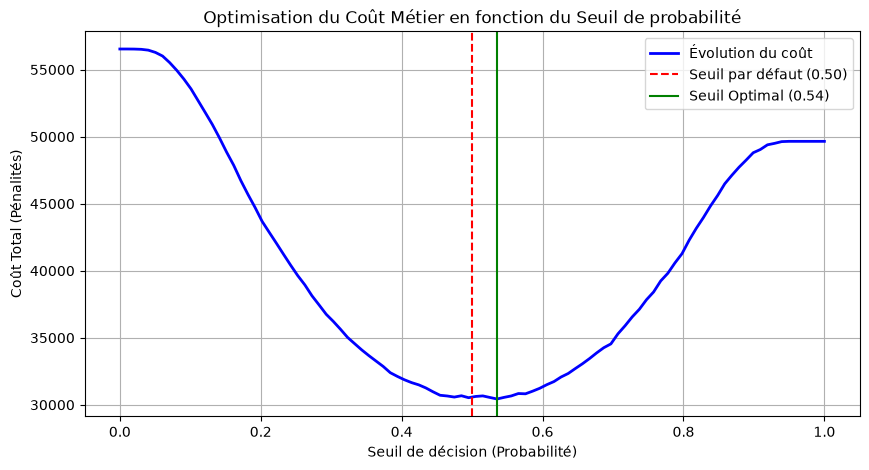

✅ Paramètre 'optimal_threshold' (0.54) ajouté au run d9852deeba8b4764a422f1d167ad0667
🏷️ Tag 'optimal_threshold' = 0.54 posé sur la version 1 de CreditScoringModel


In [5]:
# 1. On récupère les probabilités déjà calculées par notre modèle sur le jeu de test
# (Assurez-vous que la cellule précédente a bien tourné et que y_pred_proba existe)
probabilites = y_pred_proba

# 2. On prépare des listes pour stocker nos résultats
seuils = np.linspace(0.0, 1.0, 100) # 100 seuils entre 0 et 1 (0.01, 0.02...)
couts_metier = []

# Variables pour retenir le meilleur scénario
meilleur_seuil = 0.5
cout_minimum = float('inf')

print("🔍 Recherche du seuil optimal en cours...")

# 3. La boucle d'optimisation
for seuil in seuils:
    # On crée nos propres prédictions : 1 si proba > seuil, sinon 0
    predictions_custom = (probabilites >= seuil).astype(int)
    
    # On calcule la matrice de confusion pour ce seuil précis
    tn, fp, fn, tp = confusion_matrix(y_test, predictions_custom).ravel()
    
    # On calcule le coût avec les pénalités de Michaël (FN = 10, FP = 1)
    cout = (fn * 10) + (fp * 1)
    couts_metier.append(cout)
    
    # Si c'est le coût le plus bas jamais vu, on sauvegarde le seuil
    if cout < cout_minimum:
        cout_minimum = cout
        meilleur_seuil = seuil

print(f"✅ Terminé !")
print(f"💰 Coût avec le seuil par défaut (0.5) : {couts_metier[50]}")
print(f"🏆 Coût MINIMUM trouvé            : {cout_minimum}")
print(f"🎯 MEILLEUR SEUIL À APPLIQUER      : {meilleur_seuil:.2f}")

# --- 4. PREUVE VISUELLE POUR LA SOUTENANCE ---
plt.figure(figsize=(10, 5))
plt.plot(seuils, couts_metier, label="Évolution du coût", color='blue', linewidth=2)
plt.axvline(x=0.5, color='red', linestyle='--', label="Seuil par défaut (0.50)")
plt.axvline(x=meilleur_seuil, color='green', linestyle='-', label=f"Seuil Optimal ({meilleur_seuil:.2f})")

plt.title("Optimisation du Coût Métier en fonction du Seuil de probabilité")
plt.xlabel("Seuil de décision (Probabilité)")
plt.ylabel("Coût Total (Pénalités)")
plt.legend()
plt.grid(True)
plt.show()

# --- 5. AJOUT DU SEUIL OPTIMAL AU RUN ET À LA VERSION ENREGISTRÉE ---

# a) On rouvre le run de la cellule 1 pour logger le seuil comme paramètre
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_param("optimal_threshold", round(meilleur_seuil, 4))

print(f"✅ Paramètre 'optimal_threshold' ({meilleur_seuil:.2f}) ajouté au run {run.info.run_id}")

# b) On retrouve la version du modèle enregistrée pour ce run, et on la tague aussi
client = mlflow.tracking.MlflowClient()
mv = client.search_model_versions(f"run_id='{run.info.run_id}'")[0]

client.set_model_version_tag(
    name="CreditScoringModel",
    version=mv.version,
    key="optimal_threshold",
    value=str(round(meilleur_seuil, 4))
)
print(f"🏷️ Tag 'optimal_threshold' = {meilleur_seuil:.2f} posé sur la version {mv.version} de CreditScoringModel")

`Observation`
- Le seuil est très proche de celui par default ce qui améliore peu le coût metier.
- L'une des causes est peut-être le rééquilibrage mathématique par balanced durant le modèle qui fausse le resultat.

****
TRAIN V2
****

In [6]:
print("\n🚀 Lancement de l'expérience n°2 : Modèle naturel")

# On s'assure d'être dans la bonne expérience
mlflow.set_experiment(EXPERIMENT_NAME)

# On lance le Run
with mlflow.start_run(run_name="LGBM_Unbalanced") as run:
    
    # 1. Modèle SANS class_weight='balanced'
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    # Entraînement
    model.fit(X_train, y_train)
    
    # 2. Prédictions et Probabilités (seuil par défaut à 0.5)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 3. Calcul des métriques au seuil de 0.5
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    cost = (fn * FN_COST) + (fp * FP_COST)

    # 4. Enregistrement dans MLflow
    # On log explicitement qu'on n'a pas utilisé de class_weight
    mlflow.log_param("class_weight", "None") 
    
    mlflow.log_metrics({
            "test_auc": auc,
            "test_accuracy": acc,
            "business_cost": cost,
            "false_positives": fp,
            "false_negatives": fn,
            "true_negatives": tn,
            "true_positives": tp,
    })
    
    print(f"✅ Modèle entraîné et évalué au seuil de 0.5 !")
    print(f"📊 AUC Score : {auc:.4f}")
    print(f"📊 Accuracy  : {acc:.4f}")
    print(f"💰 Coût Métier : {cost} pénalités (FN={fn}, FP={fp})")
    
    register_and_promote(run.info.run_id, business_cost=cost)


🚀 Lancement de l'expérience n°2 : Modèle naturel


2026/09/12 16:17:14 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.248284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81180
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 573
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


2026/09/12 16:17:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/09/12 16:17:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/

✅ Modèle entraîné et évalué au seuil de 0.5 !
📊 AUC Score : 0.7813
📊 Accuracy  : 0.9200
💰 Coût Métier : 47762 pénalités (FN=4760, FP=162)
📦 Version 2 enregistrée pour 'CreditScoringModel' (coût métier = 47762).
✅ Alias 'prod' déjà sur la meilleure version (v1, coût = 30650.0).


Created version '2' of model 'CreditScoringModel'.


`Observation`
- On constate que le accuray augmente, ce qui est logique avec notre déséquilibre, le modèle capture la prédominance des profils non risqués. On peut voir quel es faux positive on considérablement baissé au profil des faux negatifs qui on eu une croissance inverse.
- Le rééquilibrage balanced avait donc un bonne impact sur le resultat.

****
SEARCH SEUIL V2
****

🔍 Recherche du seuil optimal en cours...
✅ Terminé !
💰 Coût avec le seuil par défaut (0.5) : 47841
🏆 Coût MINIMUM trouvé            : 30508
🎯 MEILLEUR SEUIL À APPLIQUER      : 0.09


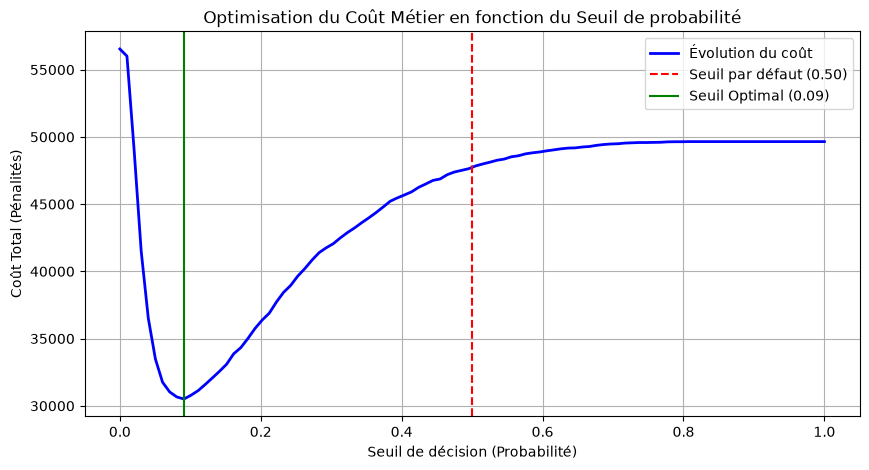

In [7]:
# 1. On récupère les probabilités déjà calculées par notre modèle sur le jeu de test
# (Assurez-vous que la cellule précédente a bien tourné et que y_pred_proba existe)
probabilites = y_pred_proba

# 2. On prépare des listes pour stocker nos résultats
seuils = np.linspace(0.0, 1.0, 100) # 100 seuils entre 0 et 1 (0.01, 0.02...)
couts_metier = []

# Variables pour retenir le meilleur scénario
meilleur_seuil = 0.5
cout_minimum = float('inf')

print("🔍 Recherche du seuil optimal en cours...")

# 3. La boucle d'optimisation
for seuil in seuils:
    # On crée nos propres prédictions : 1 si proba > seuil, sinon 0
    predictions_custom = (probabilites >= seuil).astype(int)
    
    # On calcule la matrice de confusion pour ce seuil précis
    tn, fp, fn, tp = confusion_matrix(y_test, predictions_custom).ravel()
    
    # On calcule le coût avec les pénalités de Michaël (FN = 10, FP = 1)
    cout = (fn * 10) + (fp * 1)
    couts_metier.append(cout)
    
    # Si c'est le coût le plus bas jamais vu, on sauvegarde le seuil
    if cout < cout_minimum:
        cout_minimum = cout
        meilleur_seuil = seuil

print(f"✅ Terminé !")
print(f"💰 Coût avec le seuil par défaut (0.5) : {couts_metier[50]}")
print(f"🏆 Coût MINIMUM trouvé            : {cout_minimum}")
print(f"🎯 MEILLEUR SEUIL À APPLIQUER      : {meilleur_seuil:.2f}")

# --- 4. PREUVE VISUELLE POUR LA SOUTENANCE ---
plt.figure(figsize=(10, 5))
plt.plot(seuils, couts_metier, label="Évolution du coût", color='blue', linewidth=2)
plt.axvline(x=0.5, color='red', linestyle='--', label="Seuil par défaut (0.50)")
plt.axvline(x=meilleur_seuil, color='green', linestyle='-', label=f"Seuil Optimal ({meilleur_seuil:.2f})")

plt.title("Optimisation du Coût Métier en fonction du Seuil de probabilité")
plt.xlabel("Seuil de décision (Probabilité)")
plt.ylabel("Coût Total (Pénalités)")
plt.legend()
plt.grid(True)
plt.show()

`Observation`
- Le seuil ici est plus proche de ce qui était attendu logiquement mais les résultats reste moins bon que sur le seuil du modèle balanced, même s l'ecart n'est pas astronomique (>100 coût).
- Le balanced avec donc bien un fort impact sur le resultat du seuil egalement, mais tout comme pour le modèle cela reste positif.

****
TRAIN CROSS
****

In [8]:
# --- VALIDATION CROISÉE STRATIFIÉE (5-FOLD) DU MODÈLE DE BASE ---
from sklearn.model_selection import StratifiedKFold

print("\n🚀 Lancement de la Validation Croisée (Stratified 5-Fold)...")

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

auc_scores = []
business_costs = []
accuracies = []

# Désactivation temporaire de l'autolog pour éviter de créer un run par fold
mlflow.lightgbm.autolog(disable=True)
mlflow.set_experiment(EXPERIMENT_NAME)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

    model_fold = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model_fold.fit(X_tr, y_tr)

    val_probas = model_fold.predict_proba(X_va)[:, 1]
    val_preds = (val_probas >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_va, val_preds).ravel()
    auc = roc_auc_score(y_va, val_probas)
    acc = accuracy_score(y_va, val_preds)
    cost = (fn * FN_COST) + (fp * FP_COST)

    auc_scores.append(auc)
    business_costs.append(cost)
    accuracies.append(acc)

    print(f"Fold {fold + 1}/{n_splits} - AUC: {auc:.4f} | Coût métier (seuil 0.5): {cost}")

# Synthèse statistique
mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)
mean_cost = np.mean(business_costs)
std_cost = np.std(business_costs)
mean_acc = np.mean(accuracies)

print("\n📊 --- SYNTHÈSE DE LA VALIDATION CROISÉE ---")
print(f"AUC moyen       : {mean_auc:.4f} (+/- {std_auc:.4f})")
print(f"Coût métier moy : {mean_cost:.1f} (+/- {std_cost:.1f})")
print(f"Accuracy moyen  : {mean_acc:.4f}")

# Traçabilité MLflow
with mlflow.start_run(run_name="LGBM_Baseline_Stratified_CV"):
    mlflow.log_params({
        "cv_folds": n_splits,
        "class_weight": "balanced",
        "fn_cost": FN_COST,
        "fp_cost": FP_COST,
    })
    mlflow.log_metrics({
        "cv_mean_auc": mean_auc,
        "cv_std_auc": std_auc,
        "cv_mean_business_cost": mean_cost,
        "cv_std_business_cost": std_cost,
        "cv_mean_accuracy": mean_acc,
    })

print("✅ Métriques de validation croisée enregistrées dans MLflow !")


🚀 Lancement de la Validation Croisée (Stratified 5-Fold)...
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.208820 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81092
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 572
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Fold 1/5 - AUC: 0.7781 | Coût métier (seuil 0.5): 24815
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.205584 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81112
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 573
[LightGBM] [Info] [bina

`Observation`
- La stabilité remarquable de l'AUC et du coût métier à travers les 5 plis (très faibles écarts-types) confirme que le modèle ne souffre pas de variance excessive liée au découpage des données. Il généralise de manière homogène sur l'ensemble du dataset. Le niveau d'accuracy (~73 %) reste conforme aux attentes compte tenu de la pénalisation par rééquilibrage qui privilégie la détection des profils à risque au détriment des faux positifs.

****
OPTUNA
****

In [9]:
print("\n🚀 Lancement de la recherche intelligente avec OPTUNA (5-Fold CV, objectif = AUC)...")

mlflow.lightgbm.autolog(disable=True)
mlflow.set_experiment(EXPERIMENT_NAME)

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 350, 700),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 70),
        "max_depth": trial.suggest_int("max_depth", 10, 35),
        "min_child_samples": trial.suggest_int("min_child_samples", 75, 250),
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    fold_aucs = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(**param)
        model.fit(X_tr, y_tr)

        val_probas = model.predict_proba(X_va)[:, 1]
        fold_aucs.append(roc_auc_score(y_va, val_probas))

    return float(np.mean(fold_aucs))


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

with mlflow.start_run(run_name="Optuna_HyperTuning"):
    study = optuna.create_study(direction="maximize", sampler=sampler)  # on maximise l'AUC
    study.optimize(objective, n_trials=20)

    best_cv_auc = study.best_value
    best_params = study.best_params

    mlflow.log_params(best_params)
    mlflow.log_metric("mean_cv_auc", best_cv_auc)
    mlflow.log_param("tuning_framework", "Optuna")
    mlflow.log_param("tuning_objective", "auc")
    mlflow.log_param("cv_folds", N_SPLITS)

    print("\n✅ OPTIMISATION TERMINÉE !")
    print(f"🏆 AUC moyenne (CV) du modèle CHAMPION : {best_cv_auc:.4f}")
    print("⚙️ Meilleurs paramètres :", best_params)

[I 2026-09-12 16:18:09,596] A new study created in memory with name: no-name-9c8d02af-eb22-46d4-8b14-9f2a44d142d6



🚀 Lancement de la recherche intelligente avec OPTUNA (5-Fold CV, objectif = AUC)...
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.230717 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81084
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 568
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.211103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81102
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 568
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.50000

[I 2026-09-12 16:19:42,581] Trial 0 finished with value: 0.771192060522547 and parameters: {'n_estimators': 481, 'learning_rate': 0.0862735828664018, 'num_leaves': 57, 'max_depth': 25, 'min_child_samples': 102}. Best is trial 0 with value: 0.771192060522547.


[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.217008 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81082
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 567
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.214516 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81100
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 567
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGB

[I 2026-09-12 16:22:05,367] Trial 1 finished with value: 0.7636173171709671 and parameters: {'n_estimators': 404, 'learning_rate': 0.005950295391592125, 'num_leaves': 64, 'max_depth': 25, 'min_child_samples': 199}. Best is trial 0 with value: 0.771192060522547.


...

[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.221135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81082
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 567
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.216576 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81100
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 567
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGB

[I 2026-09-12 17:02:22,276] Trial 18 finished with value: 0.7834524217880667 and parameters: {'n_estimators': 606, 'learning_rate': 0.02005403051085393, 'num_leaves': 53, 'max_depth': 17, 'min_child_samples': 225}. Best is trial 18 with value: 0.7834524217880667.


[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.218768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81082
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 567
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.232260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81100
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 567
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGB

[I 2026-09-12 17:05:32,332] Trial 19 finished with value: 0.7834028001851395 and parameters: {'n_estimators': 611, 'learning_rate': 0.02115129200434769, 'num_leaves': 54, 'max_depth': 17, 'min_child_samples': 226}. Best is trial 18 with value: 0.7834524217880667.



✅ OPTIMISATION TERMINÉE !
🏆 AUC moyenne (CV) du modèle CHAMPION : 0.7835
⚙️ Meilleurs paramètres : {'n_estimators': 606, 'learning_rate': 0.02005403051085393, 'num_leaves': 53, 'max_depth': 17, 'min_child_samples': 225}


`Observation`
- L'optimisation bayésienne avec Optuna a été menée sur 20 essais avec, cette fois, l'**AUC moyenne en validation croisée (5-fold)** comme métrique cible, et non plus le coût métier directement. Le meilleur essai (Trial 18) atteint une AUC moyenne de 0.7835, contre 0.7712 pour le premier essai (Trial 0) — un gain de +0.012 point d'AUC. Les paramètres retenus par le modèle champion sont : n_estimators = 606, learning_rate ≈ 0.0201, num_leaves = 53, max_depth = 17 et min_child_samples = 225.
- Le coût métier correspondant à ces hyperparamètres n'est pas mesuré à ce stade : il sera calculé dans une étape séparée, une fois le seuil de décision optimal déterminé sur des prédictions out-of-fold (cf. section suivante), puis validé une seule fois sur le jeu de test.

`Interprétation`
- Optuna a favorisé un modèle avec un grand nombre d'arbres (606) mais une structure relativement contrainte (num_leaves = 53 pour une profondeur max de 17), associé à un pas d'apprentissage prudent (0.0201). Ce réglage permet au modèle d'affiner ses règles de décision progressivement tout en limitant le risque de surapprentissage.
- On note également que plusieurs essais avec des **learning_rate** plus élevés (Trial 1, 6, 17) ou des profondeurs plus faibles combinées à des **learning_rate** élevés (Trial 10-15) obtiennent des AUC nettement inférieures ou stagnantes, ce qui confirme qu'un compromis entre nombre d'arbres élevé et apprentissage lent est ici plus performant pour ce jeu de données.

`Pourquoi optimiser l'AUC plutôt que le coût métier directement`
- Le coût métier dépend intrinsèquement du **seuil de décision** choisi (à partir de quelle probabilité on refuse un crédit). Rechercher, à l'intérieur de chaque fold de validation croisée, le seuil qui minimise le coût introduit un biais d'optimisme : le seuil s'ajuste au bruit spécifique de chaque petit échantillon de validation plutôt qu'à un comportement généralisable du modèle. Répété sur 5 folds indépendants, cet effet s'accumule et produit une estimation de coût artificiellement basse, non représentative de la performance réelle en production.
- L'AUC, à l'inverse, ne dépend d'aucun seuil : elle mesure uniquement la capacité du modèle à **ordonner correctement** les clients selon leur risque de défaut, quel que soit l'endroit où l'on positionnera ensuite la barre de décision. C'est donc une métrique stable et comparable d'un essai à l'autre, sans risque de sur-ajustement lié au choix du seuil.
- La recherche du seuil optimal et donc du coût métier réel est effectuée dans un second temps, une seule fois, sur les prédictions out-of-fold du modèle retenu par Optuna, avant validation finale sur le jeu de test jamais utilisé jusque-là. Cette séparation en trois étapes (hyperparamètres → seuil → évaluation finale) garantit que chaque métrique est mesurée sur des données qu'elle n'a pas contribué à optimiser.

****
MODELE CHAMPION
****

In [18]:
print("\n🚀 Entraînement du Modèle Champion avec study.best_params...")
mlflow.lightgbm.autolog(disable=False)
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="LGBM_Champion_Final") as run:
    champion_params = study.best_params.copy()
    champion_params.update({
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    })

    # --- 1. Modèle final entraîné sur tout X_train ---
    model_champion = lgb.LGBMClassifier(**champion_params)
    model_champion.fit(X_train, y_train)

    # --- 2. Recherche du seuil sur des prédictions OUT-OF-FOLD (pas sur X_test !) ---
    print("🔍 Calcul des prédictions out-of-fold pour la recherche de seuil...")
    oof_probas = cross_val_predict(
        lgb.LGBMClassifier(**champion_params),
        X_train, y_train,
        cv=skf,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    seuils = np.linspace(0.0, 1.0, 100)
    best_cost_oof = float("inf")
    best_threshold = 0.5

    for seuil in seuils:
        preds_oof = (oof_probas >= seuil).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, preds_oof).ravel()
        cost = fn * FN_COST + fp * FP_COST
        if cost < best_cost_oof:
            best_cost_oof = cost
            best_threshold = seuil

    print(f"🎯 Seuil optimal (out-of-fold) : {best_threshold:.2f}")
    print(f"💰 Coût métier out-of-fold     : {best_cost_oof}")

    # --- 3. Évaluation finale, UNE SEULE FOIS, sur X_test avec le seuil déjà figé ---
    y_pred_proba_test = model_champion.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_pred_proba_test)

    y_pred_test = (y_pred_proba_test >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
    final_cost = fn * FN_COST + fp * FP_COST
    acc = accuracy_score(y_test, y_pred_test)

    # --- 4. Logs MLflow ---
    mlflow.log_metrics({
            "test_auc": test_auc,
            "test_accuracy": acc,
            "business_cost": final_cost,
            "false_positives": fp,
            "false_negatives": fn,
            "true_negatives": tn,
            "true_positives": tp,
            "optimal_threshold": round(best_threshold, 4),
        })

    # --- 5. Enregistrement + promotion automatique si meilleur ---
    register_and_promote(
        run.info.run_id,
        business_cost=final_cost,
        optimal_threshold=best_threshold,
    )

print("\n✅ ENTRAÎNEMENT TERMINÉ !")
print(f"📊 AUC Test          : {test_auc:.4f}")
print(f"🎯 Seuil Optimal     : {best_threshold:.2f}")
print(f"💰 Coût Métier Test  : {final_cost} (FN={fn}, FP={fp})")


🚀 Entraînement du Modèle Champion avec study.best_params...


2026/09/12 18:21:35 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.253457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81168
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 567
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2026/09/12 18:22:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/09/12 18:22:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/

🔍 Calcul des prédictions out-of-fold pour la recherche de seuil...
🎯 Seuil optimal (out-of-fold) : 0.47
💰 Coût métier out-of-fold     : 121462


2026/09/12 18:25:22 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Nérion\Documents\Code\5_OpenClassRooms\5_MLOps_Part1\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
Registered model 'CreditScoringModel' already exists. Creating a new version of this model...
2026/09/12 18:25:22 W

🏷️ Seuil optimal (0.47) taggé sur la version 4.
📦 Version 4 enregistrée pour 'CreditScoringModel' (coût métier = 30160).
🏆 Alias 'prod' mis à jour → version 4 (coût métier = 30160.0).

✅ ENTRAÎNEMENT TERMINÉ !
📊 AUC Test          : 0.7871
🎯 Seuil Optimal     : 0.47
💰 Coût Métier Test  : 30160 (FN=1500, FP=15160)


Created version '4' of model 'CreditScoringModel'.


`Observation`
- Le réentraînement final du modèle Champion donne un score AUC de 0.7871, un seuil optimal fixé à 0.47 et confirme le coût métier minimum de 30 160 pénalités (décomposé en 1500 Faux Négatifs et 15160 Faux Positifs). Le graphique d'importance des variables montre une nette prédominance des indicateurs financiers globaux et des évaluations de risque externes.

`Interprétation`
- Pouvoir discriminant (AUC 0.7871) : C'est notre meilleur score AUC depuis le début du projet, prouvant que l'optimisation des hyperparamètres a renforcé la capacité globale du modèle à ordonner les profils du plus risqué au moins risqué.
- Le coût metier le plus bas à était obtenu avec une legère augmentation des faux positifs (15 140 à 15 160) mais une petite diminution des faux negatif (1551 à 1500)